In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster
import rasterio
import numpy as np
import glob
import os
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape
from shapely.geometry import Point
from libpysal.weights import lag_spatial
from esda.moran import Moran_Local
import matplotlib.patches as mpatches
from shapely.geometry import box
import rasterio.mask
from shapely import make_valid

In [6]:

def crear_pesos(gdf, metodo='queen', k=4):
    """
    Crea la matriz de pesos espaciales.
    """
    if metodo == 'queen':
        w = Queen.from_dataframe(gdf)
    elif metodo == 'knn':
        w = KNN.from_dataframe(gdf, k=k)
    else:
        raise ValueError("Método no válido. Usa 'queen' o 'knn'.")
    w.transform = 'r'
    return w



In [7]:

def calcular_moran(gdf, variable, w):
    """
    Calcula el Índice de Moran Global.
    """
    y = gdf[variable].values
    moran = Moran(y, w)
    return moran


In [10]:
def plot_lisa(zona_diss, field_correl,w):
    x = zona_diss[f'{field_correl}_norm'].values.astype('float64')
    y = zona_diss[f'slag_{field_correl}']
    lisa = Moran_Local(x, w)
    zona_diss['quadrant'] = lisa.q
    zona_diss['significant'] = lisa.p_sim < 0.05

    quads={1:'HH',2:'LH',3:'LL',4:'HL'} #antireloj

    palette = {'LL': 'blue','HH':'red','LH':'#83cef4','HL':'#e59696'}
                
    zona_diss['quad_class'] = [quads[x] for x in zona_diss['quadrant']]

    HHm=(zona_diss['significant']) & (zona_diss['quadrant']==1) 
    LLm=(zona_diss['significant']) & (zona_diss['quadrant']==3) 
    HLm=(zona_diss['significant']) & (zona_diss['quadrant']==4) 
    LHm=(zona_diss['significant']) & (zona_diss['quadrant']==2) 

    f,(ax,ax2) = plt.subplots(1,2, figsize=(20, 10))

    #Moran
    m,b= np.polyfit(x, y, 1)
    print('Slope:',m)
    ax.plot(x,y,'o',color='gray',markersize=4)

    ax.plot(x[HHm],y[HHm],'o',color='r',markersize=6)
    ax.plot(x[LLm],y[LLm],'o',color='b',markersize=6)
    ax.plot(x[LHm],y[LHm],'o',color='#83cef4',markersize=6)
    ax.plot(x[HLm],y[HLm],'o',color='#e59696',markersize=6)

    ax.plot(x,m*x+b,ls='--')
    ax.set_xlabel(field_correl,fontsize=16)
    ax.set_ylabel('Spatial Lag' ,fontsize=16)
    ax.set_xlim(-1,3)
    ax.set_ylim(-1,3)
    ax.axhline(y=0,ls='--',color='k')
    ax.axvline(x=0,ls='--',color='k')

        
    mi = Moran(x, w)
    ax.text(1,-0.5,'I Moran:%.2f, p_sim:%.4f'%(mi.I,mi.p_sim),fontsize=16)

    #mapa
    sig=zona_diss[zona_diss['significant']]
    zona_diss.plot(color='gray',ax=ax2)

    #datsig={'HH':HH[HHm],'LL':LL[LLm],'LH':LH[LHm],'HL':HL[HLm]}
    datsig={'HH':HHm,'LL':LLm,'LH':LHm,'HL':HLm}

    handles=[]
    for ctype in datsig.keys():
        print(ctype)
        data=zona_diss[datsig[ctype]]
        # Definir color para cada grupo
        color = palette[ctype]
        
        # Graficar grupo en el color correspondiente y agregar a leyenda
        hand=data.plot(color=color,ax=ax2,label=ctype)
        handles.append(mpatches.Patch(color=color, label=ctype))

    plt.legend(handles=handles,loc='best',fontsize=16)
    ax2.set_axis_off()
    f.suptitle('LISA para %s'%field_correl, size=16)


In [11]:

def graficar_moran_dispersion(gdf, variable, w, titulo=None):
    """
    Calcula Moran Global y genera el gráfico de dispersión de Moran.

    Parámetros:
    - gdf: GeoDataFrame con la variable.
    - variable: nombre de la columna a analizar (str).
    - w: objeto de pesos espaciales (libpysal.weights).
    - titulo: título opcional para el gráfico.
    """
    # Normalizar la variable
    Y = variable
    gdf[f'{Y}_norm'] = (gdf[Y] - gdf[Y].mean()) / gdf[Y].std()

    # Transformar pesos
    w.transform = 'r'

    # Lag espacial
    gdf[f'slag_{Y}'] = lag_spatial(w, gdf[f'{Y}_norm'])

    # Calcular Moran global
    mi = Moran(gdf[f'{Y}_norm'], w)

    # Plot
    plt.figure(figsize=(7, 7))
    x = gdf[f'{Y}_norm']
    y = gdf[f'slag_{Y}']

    plt.scatter(x, y, edgecolor='k', alpha=0.7)
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m*x + b, '--r', label='Ajuste lineal')

    plt.axhline(0, color='gray', ls='--')
    plt.axvline(0, color='gray', ls='--')
    plt.xlabel(f"{Y.upper()} Normalizado")
    plt.ylabel(f"Lag espacial de {Y.upper()}")
    plt.title(titulo or f"Gráfico de Moran - {Y.upper()}")

    # Texto con valores de Moran
    plt.text(
        0.05, y.min() + 0.2,
        f"Moran's I = {mi.I:.4f}\nP-valor = {mi.p_sim:.4f}",
        fontsize=12,
        bbox=dict(facecolor='white', alpha=0.8)
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return mi

In [12]:

def crear_cuadricula(ruta_raster, ruta_shapefile_clip, tamano_celda, epsg_salida=32612):
    # Leer shapefile zona de interés
    zona = gpd.read_file(ruta_shapefile_clip).to_crs(epsg=epsg_salida)
    print(zona.crs)
    

    with rasterio.open(ruta_raster) as src:
        bounds = src.bounds
        raster_crs = src.crs
    print(raster_crs)
    print(epsg_salida)
    # Crear cuadrícula regular
    xmin, ymin, xmax, ymax = bounds
    ancho = tamano_celda
    alto = tamano_celda

    cols = list(np.arange(xmin, xmax, ancho))
    filas = list(np.arange(ymin, ymax, alto))

    cuadros = []
    for x in cols:
        for y in filas:
            cuadro = box(x, y, x + ancho, y + alto)
            cuadros.append(cuadro)

    grid = gpd.GeoDataFrame({'geometry': cuadros}, crs=raster_crs)
    grid = grid.to_crs(epsg=epsg_salida)
    
    # Eliminar geometrías vacías o con NaN
    grid = grid[~grid["geometry"].is_empty & grid["geometry"].notna()]
    zona = zona[~zona["geometry"].is_empty & zona["geometry"].notna()]

    # Validar geometrías (forzar reparación si hay problemas)
    grid["geometry"] = grid["geometry"].buffer(0)
    zona["geometry"] = zona["geometry"].buffer(0)
    print("Grid inválidas:", grid[~grid.is_valid])
    print("Zona inválidas:", zona[~zona.is_valid])

    # Recortar la cuadrícula por zona de interés
    grid = gpd.overlay(grid, zona, how='intersection', make_valid=True)

    return grid

def promedio_por_celda(ruta_raster, grid, nombre_variable="valor"):

    valores = []
    with rasterio.open(ruta_raster) as src:
        for geom in grid.geometry:
            try:
                out_image, out_transform = rasterio.mask.mask(src, [geom], crop=True)
                data = out_image[0]
                data = data.astype('float32')
                nodata = src.nodata
                if nodata is not None:
                    data[data == nodata] = np.nan
                media = np.nanmean(data)
            except Exception as e:
                media = np.nan
            valores.append(media)

    grid[nombre_variable] = valores
    return grid

In [13]:
def calcular_media(path_carpeta, patron="*.tif", guardar_salida=None):
    archivos = sorted(glob.glob(os.path.join(path_carpeta, patron)))
    print(f"📂 {len(archivos)} archivos encontrados")

    ndvi_arrays = []
    perfil_referencia = None

    for archivo in archivos:
        with rasterio.open(archivo) as src:
            ndvi = src.read(1).astype('float32')
            ndvi[ndvi == src.nodata] = np.nan
            ndvi_arrays.append(ndvi)
            if perfil_referencia is None:
                perfil_referencia = src.profile

    ndvi_stack = np.stack(ndvi_arrays, axis=0)
    ndvi_medio = np.nanmean(ndvi_stack, axis=0)

    if guardar_salida:
        perfil_referencia.update(dtype='float32', count=1, nodata=np.nan)
        with rasterio.open(guardar_salida, 'w', **perfil_referencia) as dst:
            dst.write(ndvi_medio, 1)
        print(f"✅ Guardado en: {guardar_salida}")

    return ndvi_medio

In [14]:
zona = gpd.read_file("datos/YELL_tracts/YELL_boundary.shp")
zona = zona.to_crs(epsg=32612)

## Para LST

In [96]:
grid_promedio = gpd.read_file('datos/grids/grid_lst_2013_2024.shp')

<Axes: >

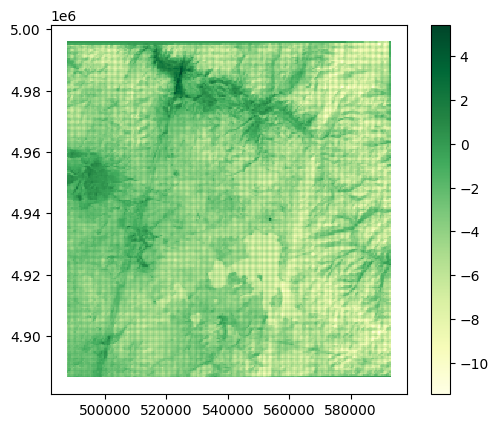

In [88]:
grid_promedio.plot(column="lst", cmap="YlGn", legend=True, markersize=5)

In [99]:
grid_promedio = gpd.overlay(grid_promedio, zona, how='intersection', make_valid=True)  

<Axes: >

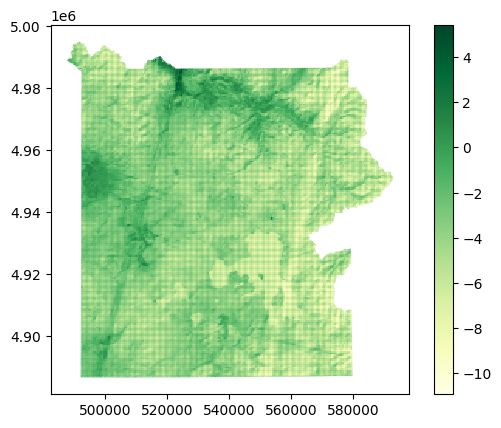

In [100]:
grid_promedio.plot(column="lst", cmap="YlGn", legend=True, markersize=5)

In [101]:
metodo_pesos = 'queen'  # o 'knn'
gdf = grid_promedio
variable = 'lst'
k = 4
w = crear_pesos(gdf, metodo=metodo_pesos, k=k)
moran = calcular_moran(gdf, variable, w)

print(f"📈 Índice de Moran para {variable}: {moran.I:.4f}")
print(f"📊 Valor p (significancia): {moran.p_sim:.4f}")
  

/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_55553/2574023376.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


📈 Índice de Moran para lst: 0.8288
📊 Valor p (significancia): 0.0010


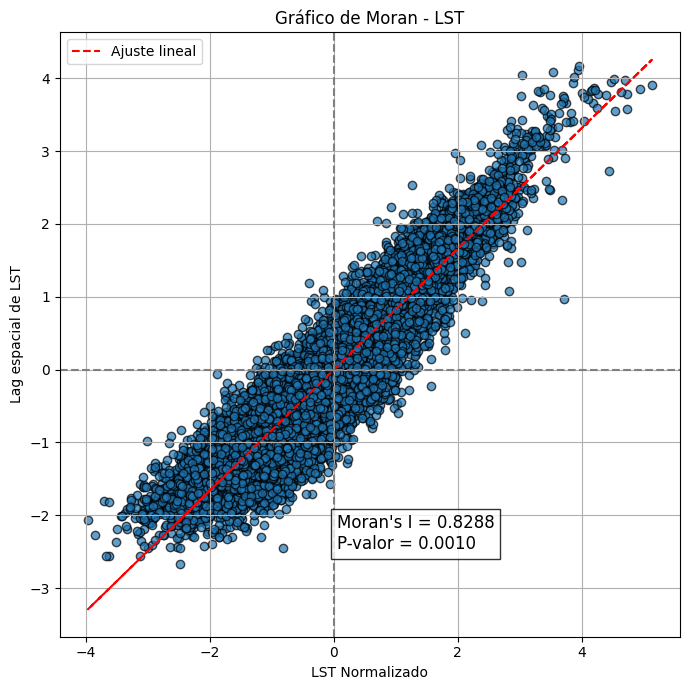

In [102]:
graficar_moran_dispersion(grid_promedio, 'lst', w)


Slope: 0.8287786297517002
HH
LL
LH
HL


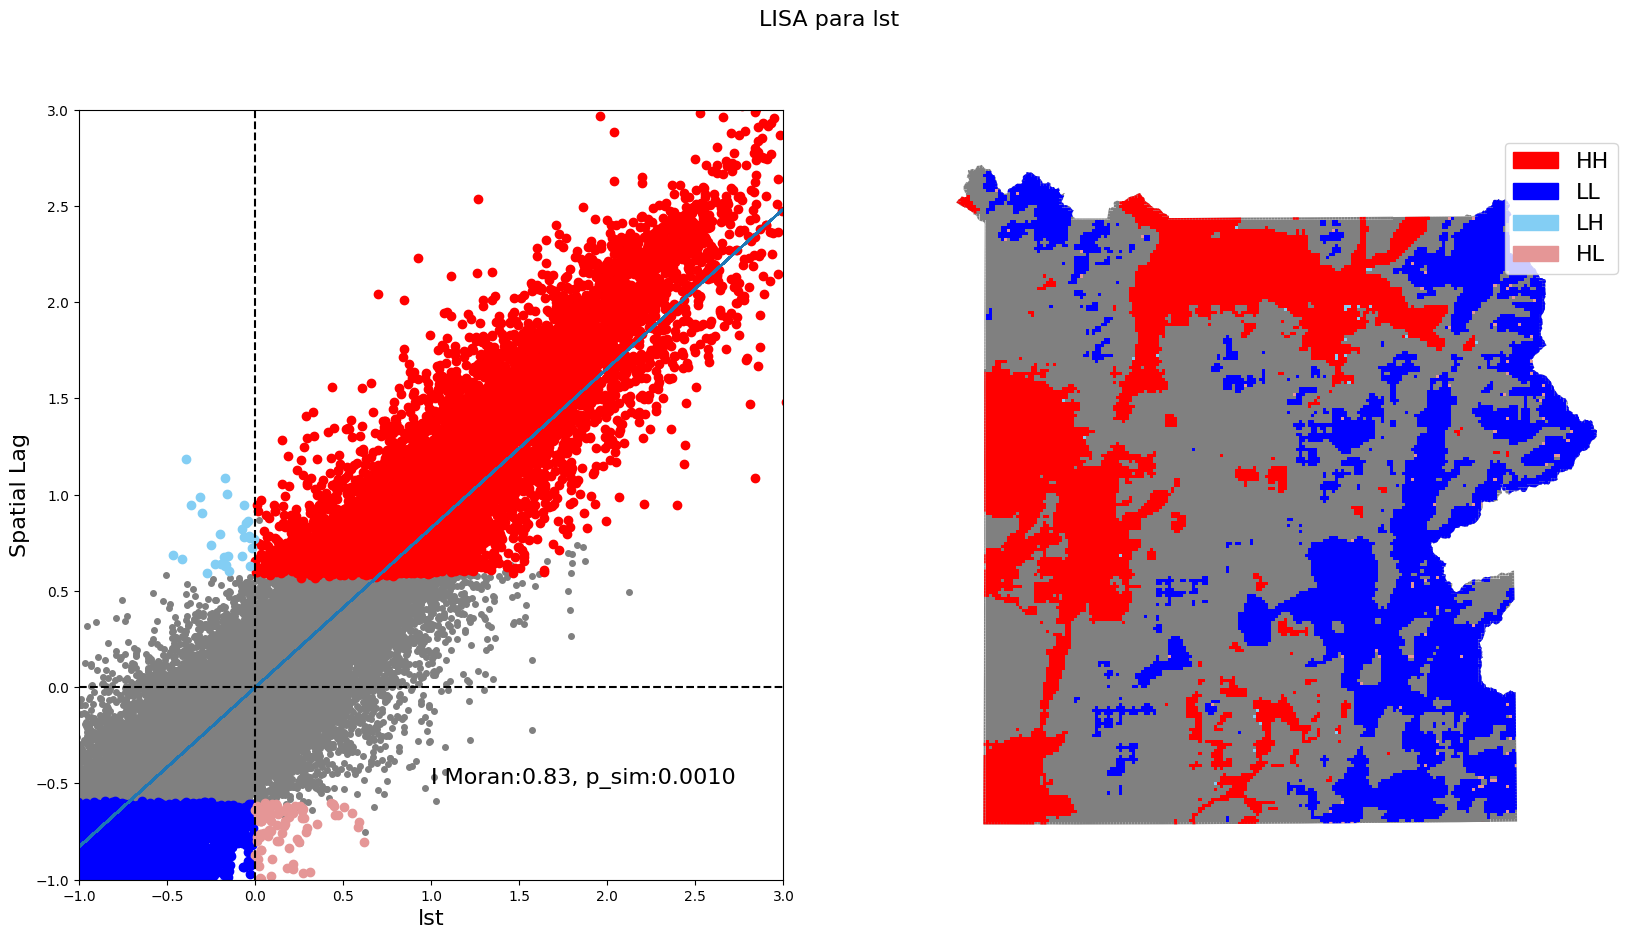

In [109]:
plot_lisa(gdf, 'lst', w)

Para 2001-2013

/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_55553/2574023376.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


📈 Índice de Moran para lst: 0.8634
📊 Valor p (significancia): 0.0010


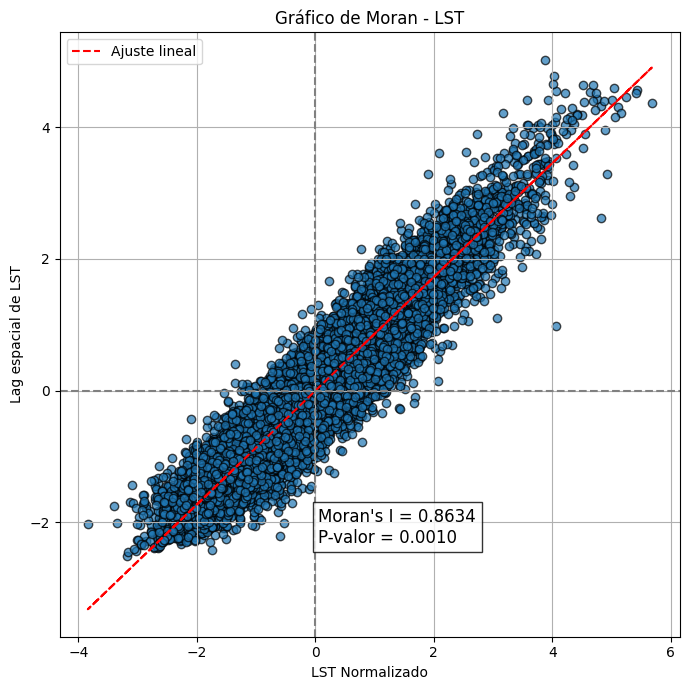

Slope: 0.8634478333015372
HH
LL
LH
HL


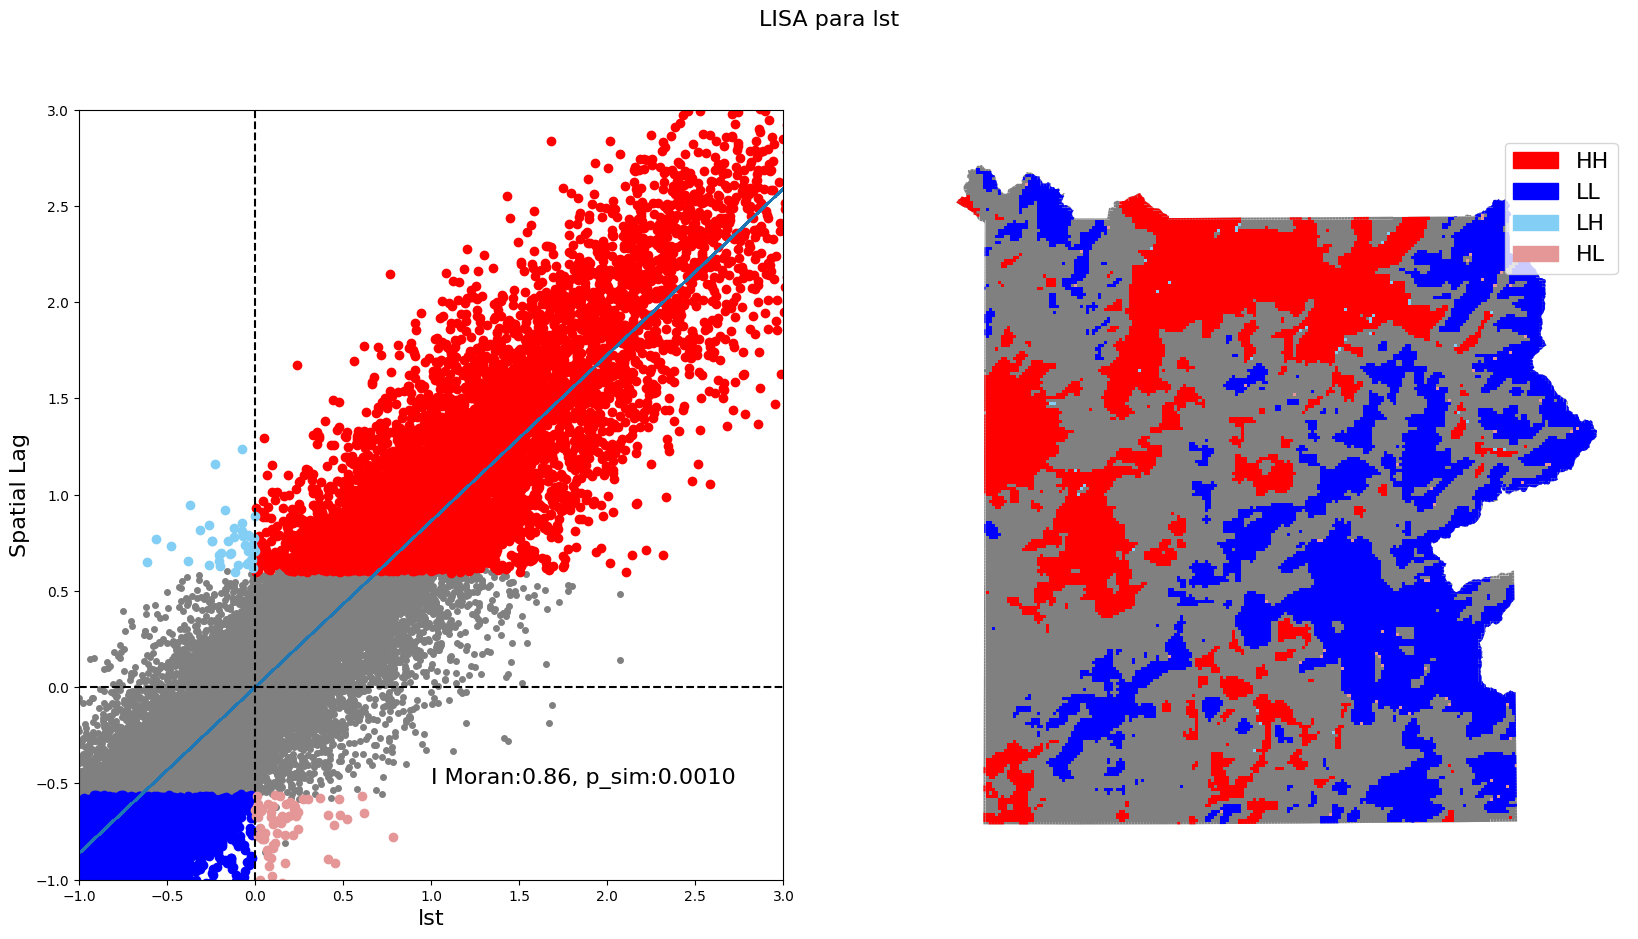

In [135]:
grid_promedio = gpd.read_file('datos/grids/grid_lst_2001_2013.shp')
grid_promedio = gpd.overlay(grid_promedio, zona, how='intersection', make_valid=True)  
metodo_pesos = 'queen'  # o 'knn'
gdf = grid_promedio
variable = 'lst'
k = 4
w = crear_pesos(gdf, metodo=metodo_pesos, k=k)
moran = calcular_moran(gdf, variable, w)

print(f"📈 Índice de Moran para {variable}: {moran.I:.4f}")
print(f"📊 Valor p (significancia): {moran.p_sim:.4f}")
graficar_moran_dispersion(grid_promedio, 'lst', w)
plot_lisa(gdf, 'lst', w)

# NDVI

/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_47813/2574023376.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


📈 Índice de Moran para NDVI: 0.8548
📊 Valor p (significancia): 0.0010


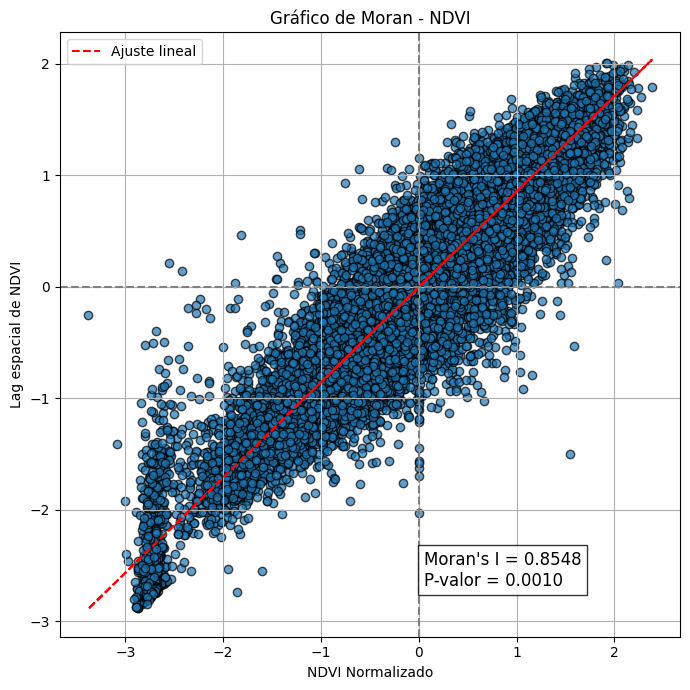

Slope: 0.8547519804629646
HH
LL
LH
HL


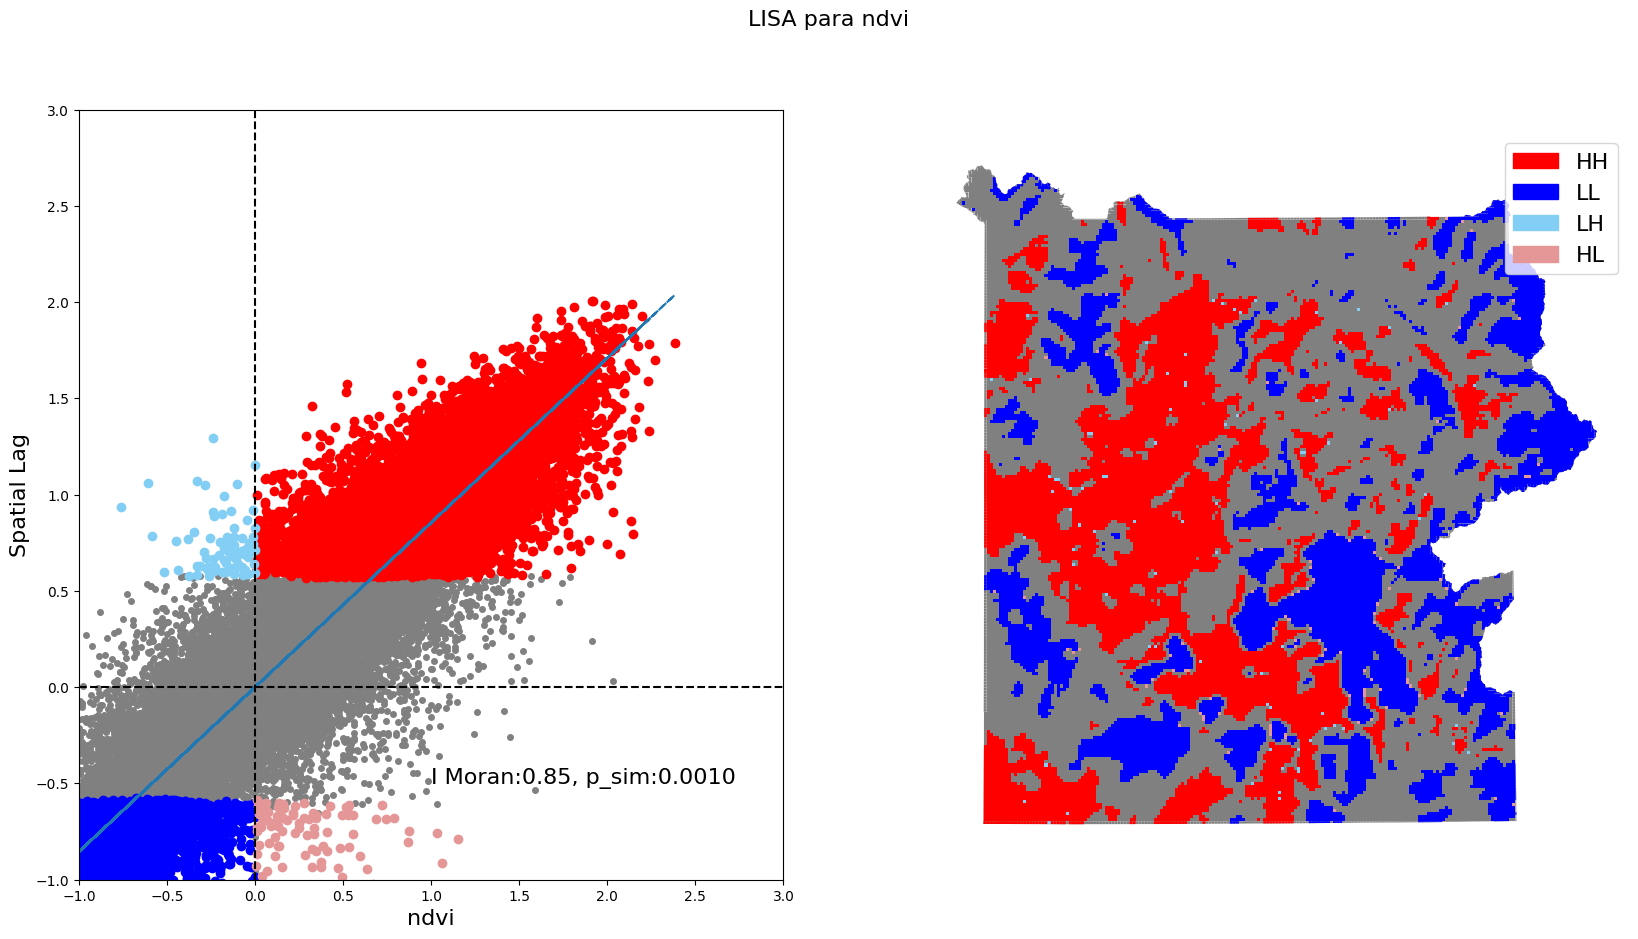

In [17]:
import pandas as pd
from shapely import wkt
#grid_promedio = gpd.overlay(gdf_resultado, zona, how='intersection', make_valid=True)  
df = pd.read_csv('datos/grid_data_2014_2024.csv')
df['geometry'] = df['geometry'].apply(wkt.loads)
df = gpd.GeoDataFrame(df, geometry='geometry')
grid_promedio_clean = df
metodo_pesos = 'queen'  # o 'knn'
gdf = grid_promedio_clean
variable = 'ndvi'
k = 4
w = crear_pesos(gdf, metodo=metodo_pesos, k=k)
moran = calcular_moran(gdf, variable, w)

print(f"📈 Índice de Moran para NDVI: {moran.I:.4f}")
print(f"📊 Valor p (significancia): {moran.p_sim:.4f}")
graficar_moran_dispersion(grid_promedio_clean, variable, w)
plot_lisa(gdf, variable, w)

/var/folders/lx/01q73krn1md9zqcwvy3rqlqh0000gn/T/ipykernel_47813/2574023376.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


📈 Índice de Moran para NDVI: 0.8729
📊 Valor p (significancia): 0.0010


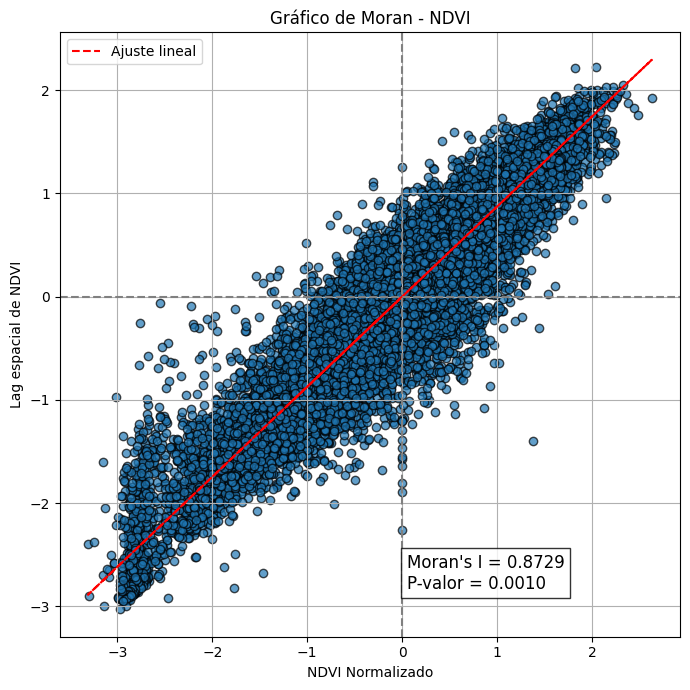

Slope: 0.8728552019552756
HH
LL
LH
HL


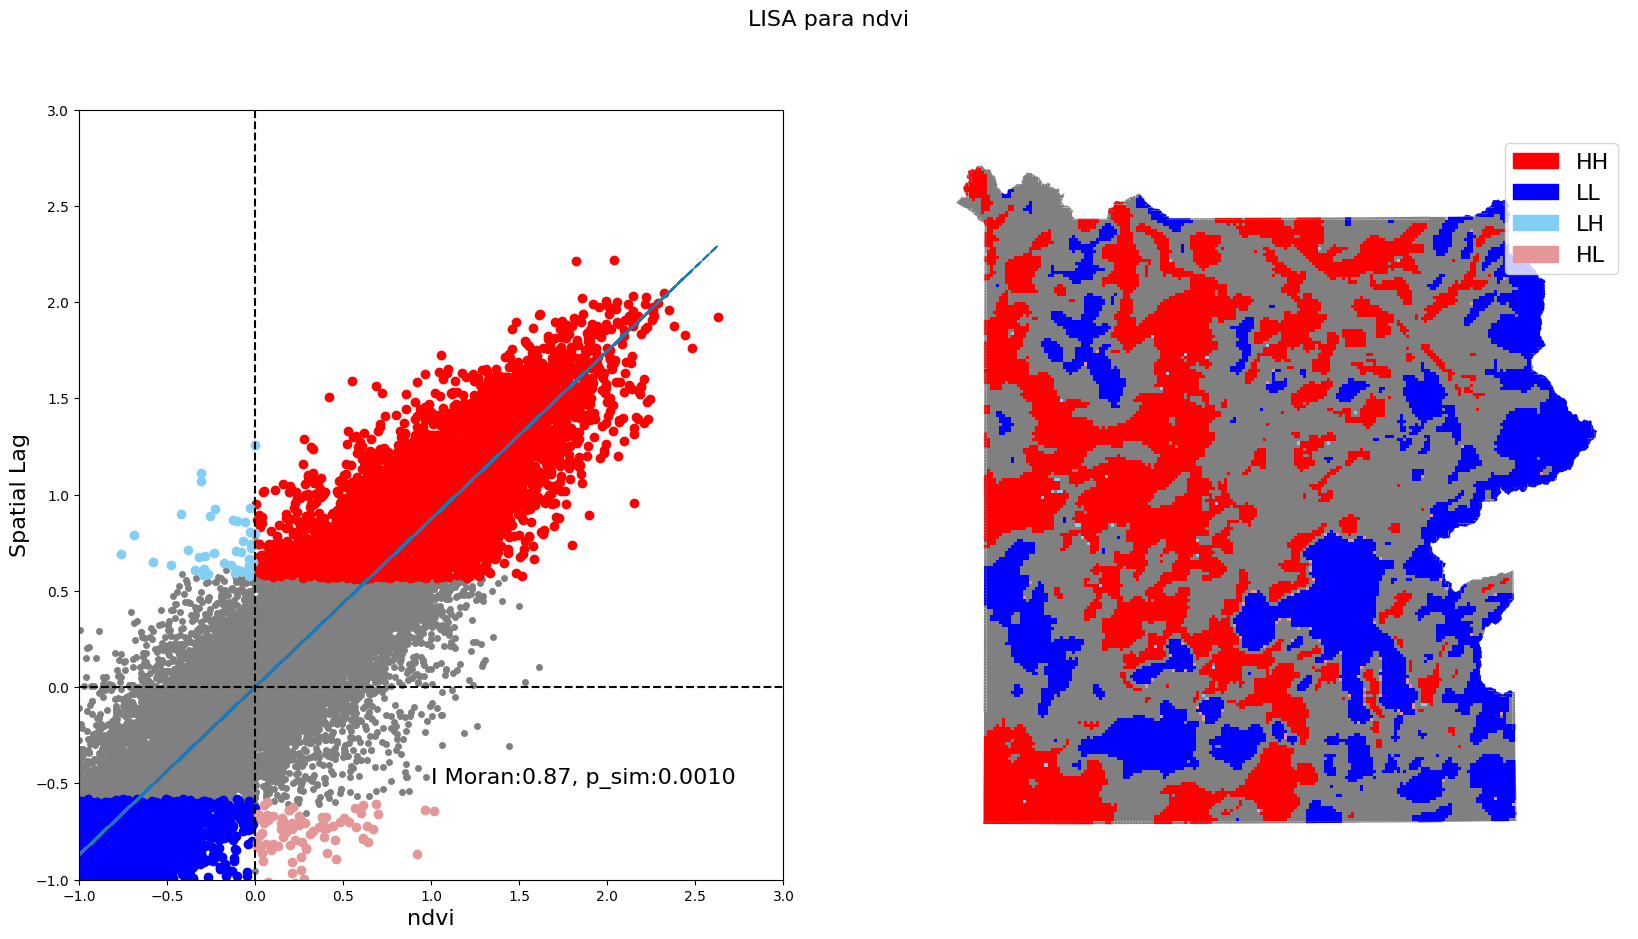

In [18]:

df = pd.read_csv('datos/grid_data_2001_2013.csv')
df['geometry'] = df['geometry'].apply(wkt.loads)
df = gpd.GeoDataFrame(df, geometry='geometry')
grid_promedio_clean = df
metodo_pesos = 'queen'  # o 'knn'
gdf = grid_promedio_clean
variable = 'ndvi'
k = 4
w = crear_pesos(gdf, metodo=metodo_pesos, k=k)
moran = calcular_moran(gdf, variable, w)

print(f"📈 Índice de Moran para NDVI: {moran.I:.4f}")
print(f"📊 Valor p (significancia): {moran.p_sim:.4f}")
graficar_moran_dispersion(grid_promedio_clean, variable, w)
plot_lisa(gdf, variable, w)